In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA
from scipy import stats
import sys
import seaborn as sns
import scipy.signal
sys.path.append("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/")
from privacy_amplification.FFT.FFT import *
import tensorflow as tf
from tensorflow.keras import layers, models
import h5py
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

2025-09-05 14:49:40.265651: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-05 14:49:40.267495: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-05 14:49:40.599568: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-05 14:49:41.508912: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Load The dataset and sort

In [2]:
all_traces = []
all_keys = []

with h5py.File("traces.h5", "r") as f:
    for batch_name in f.keys():   # iterate over batch_0, batch_1, ...
        traces = f[f"{batch_name}/traces"][:]
        keys   = f[f"{batch_name}/keys"][:]
        all_traces.append(traces)
        all_keys.append(keys)

all_traces = np.vstack(all_traces)   # combine into one big array
all_keys   = np.concatenate(all_keys)

In [3]:
def sort_set(full_set, keys_used, key_length):
    ### Do all sorteing after

    half_n = int(key_length / 2)
    repeats = len(full_set)

    data = []
    n_classes =4
    labels = []

    for i in range(repeats):
        for j in range(half_n):
            data.append(full_set[i][j])
            if (keys_used[i][2*j:2*j+2] == [0,0]).all():
                labels.append("00")
            elif (keys_used[i][2*j:2*j+2] == [0,1]).all():
                labels.append("01")
            elif (keys_used[i][2*j:2*j+2] == [1,0]).all():
                labels.append("10")
            elif (keys_used[i][2*j:2*j+2] == [1,1]).all():
                labels.append("11")


    return np.array(data), np.array(labels)

In [45]:
data, labels = sort_set(all_traces, all_keys, 8)

sigma = 2
for s in range(data.shape[0]):
    data[s] = data[s] + np.random.normal(0,sigma,data.shape[1])
    
section = 40000
data_train, data_test, label_train, label_test = train_test_split(data[0:section], labels[0:section], test_size=0.2)

le = LabelEncoder()
y_int = le.fit_transform(label_train)  # now integers 0..num_classes-1
y_test_int = le.transform(label_test)  # apply same mapping to test labels

In [44]:
hidden_dim = 500
time_steps = 4999
n_classes = 4

model = models.Sequential([
    layers.Input(shape=(time_steps,)),
    layers.Dense(hidden_dim, activation='relu'),
    layers.Dense(hidden_dim, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # <- works with integer labels',
    metrics=['accuracy']
)

In [46]:
history = model.fit(
    data_train, y_int,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8845 - loss: 0.3171 - val_accuracy: 0.9362 - val_loss: 0.1710
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9839 - loss: 0.0499 - val_accuracy: 0.9231 - val_loss: 0.2466
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9824 - loss: 0.0541 - val_accuracy: 0.9225 - val_loss: 0.2554
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9831 - loss: 0.0516 - val_accuracy: 0.9162 - val_loss: 0.3520
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9864 - loss: 0.0422 - val_accuracy: 0.9219 - val_loss: 0.3038
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9891 - loss: 0.0363 - val_accuracy: 0.9297 - val_loss: 0.2994
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9905 - loss: 0.0318 - val_accuracy: 0.9209 - val_loss: 0.3512
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9895 - loss: 0.0365 - val_accuracy: 0.

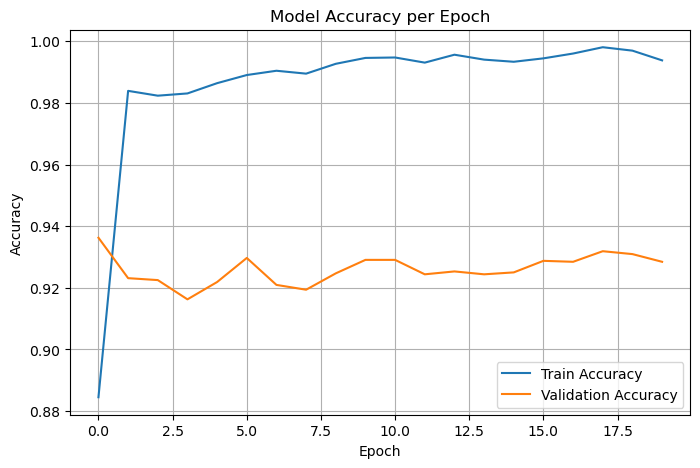

In [47]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
loss, acc = model.evaluate(data_test, y_test_int)
print(f"Test Accuracy: {acc:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.9201 - loss: 0.7890
Test Accuracy: 0.9201


In [51]:
model = models.Sequential([
    layers.Input(shape=(time_steps,1)),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # <- works with integer labels',
    metrics=['accuracy']
)

In [52]:
history = model.fit(
    data_train, y_int,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 87s 96ms/step - accuracy: 0.8737 - loss: 0.4915 - val_accuracy: 0.9375 - val_loss: 0.1746
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 88s 97ms/step - accuracy: 0.9749 - loss: 0.0701 - val_accuracy: 0.9231 - val_loss: 0.2268
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 104s 115ms/step - accuracy: 0.9879 - loss: 0.0336 - val_accuracy: 0.9578 - val_loss: 0.1401
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 108s 119ms/step - accuracy: 0.9913 - loss: 0.0245 - val_accuracy: 0.9516 - val_loss: 0.1533
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 112s 125ms/step - accuracy: 0.9934 - loss: 0.0177 - val_accuracy: 0.9334 - val_loss: 0.2513
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 113s 126ms/step - accuracy: 0.9946 - loss: 0.0158 - val_accuracy: 0.9441 - val_loss: 0.2288
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 114s 127ms/step - accuracy: 0.9955 - loss: 0.0121 - val_accuracy: 0.9400 - val_loss: 0.2743
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 115s 128ms/step - accuracy: 0.9958 - los

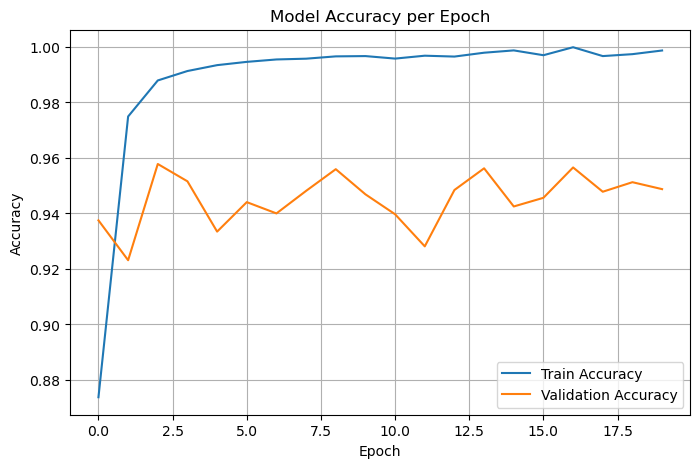

In [53]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
model.save("cnn_model.keras")  # New recommended format

In [55]:
import json

# Save history as JSON
with open("history.json", "w") as f:
    json.dump(history.history, f)

# Load it back later
with open("history.json", "r") as f:
    history_dict = json.load(f)